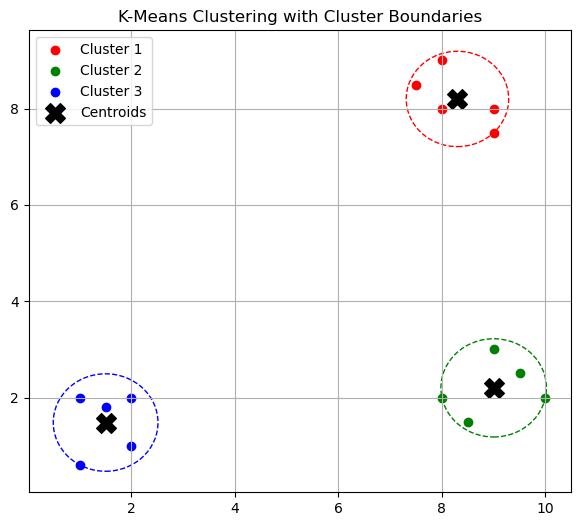

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Generate Sample Dataset
# -----------------------------
np.random.seed(42)

X = np.array([
    [1,2],[1.5,1.8],[2,1],[1,0.6],[2,2],
    [8,8],[9,8],[8,9],[7.5,8.5],[9,7.5],
    [8,2],[9,3],[10,2],[8.5,1.5],[9.5,2.5]
])

k = 3
max_iter = 100

# -----------------------------
# Initialize Centroids
# -----------------------------
centroids = X[np.random.choice(len(X), k, replace=False)]

# -----------------------------
# K-Means Algorithm
# -----------------------------
for _ in range(max_iter):

    clusters = [[] for _ in range(k)]

    # Assign points to nearest centroid
    for point in X:
        distances = np.linalg.norm(point - centroids, axis=1)
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    # Compute new centroids
    new_centroids = []

    for cluster in clusters:
        if len(cluster) > 0:
            new_centroids.append(np.mean(cluster, axis=0))
        else:
            new_centroids.append(centroids[len(new_centroids)])

    new_centroids = np.array(new_centroids)

    # Stop if centroids do not change
    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids


# -----------------------------
# Visualization
# -----------------------------
colors = ['red', 'green', 'blue']

plt.figure(figsize=(7,6))

for i, cluster in enumerate(clusters):

    cluster = np.array(cluster)

    if len(cluster) == 0:
        continue

    # plot points
    plt.scatter(cluster[:,0], cluster[:,1], c=colors[i], label=f"Cluster {i+1}")

    # draw circle around cluster
    centroid = centroids[i]
    radius = np.max(np.linalg.norm(cluster - centroid, axis=1))

    circle = plt.Circle(centroid, radius, color=colors[i], fill=False, linestyle="--")
    plt.gca().add_patch(circle)

# plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='X', s=200, label="Centroids")

plt.title("K-Means Clustering with Cluster Boundaries")
plt.legend()
plt.grid(True)
plt.show()